In [38]:
import fiftyone as fo
import pandas as pd

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
from fiftyone import ViewField as F
from torchvision.datasets import CocoDetection
from torch.utils.data import Dataset, random_split, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
import json
import math
import torch
from torch import nn

In [31]:
dataset = fo.load_dataset("open-images-dog-cat-1box")


# Create Coco Dataset Class for Loading the Dataset

In [32]:
class CocoSingleLabelDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None):
        self.base = CocoDetection(image_dir, annotation_file)
        self.transform = transform

        with open(annotation_file) as f:
            coco_data = json.load(f)
        self.id_to_label = {cat['id']: cat['name'] for cat in coco_data['categories']}
        self.label_to_index = {name: i for i, name in enumerate(sorted(set(self.id_to_label.values())))}

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, annotations = self.base[idx]

        # Get the first object’s label (you filtered for 1-box images)
        category_id = annotations[0]['category_id']
        label_name = self.id_to_label[category_id]
        label = self.label_to_index[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

# Old Transform for Cookie Cutter Model

In [ ]:
# resizes image to 28*28
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# Change Images to Grayscale

In [33]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [34]:
dataset = CocoSingleLabelDataset(
    image_dir="dogs_cats_1box/data",
    annotation_file="dogs_cats_1box/labels.json",
    transform=transform
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [35]:
train_size = math.floor(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

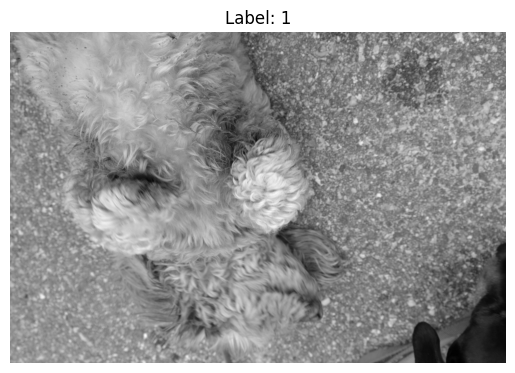

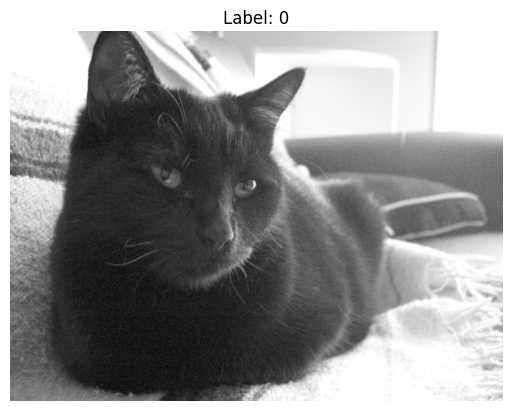

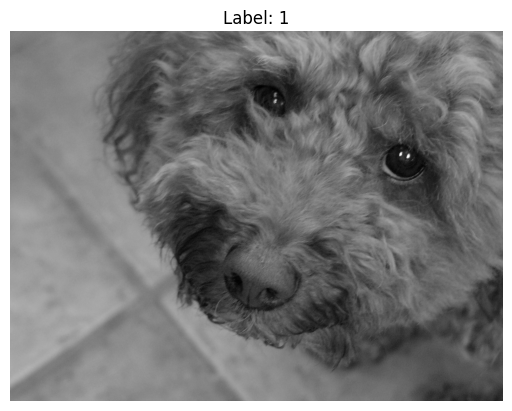

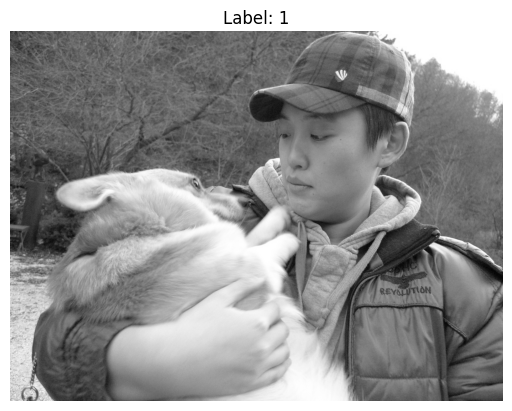

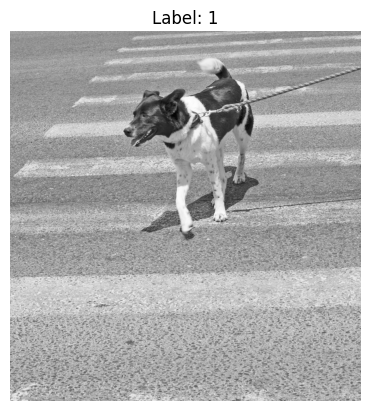

In [36]:
for i in range(5):
    image, label = train_dataset[i]
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

# Find Size of Largest Image in Dataset

In [37]:
image_dir="dogs_cats_1box/data"

max_width = 0
max_height = 0
max_file = None

for filename in os.listdir(image_dir):
    if filename.lower().endswith(('.jpg')):
        path = os.path.join(image_dir, filename)
        try:
            with Image.open(path) as img:
                width, height = img.size
                if width > max_width or height > max_height:
                    max_width = max(max_width, width)
                    max_height = max(max_height, height)
                    max_file = filename
        except Exception as e:
            print(f"Could not open {filename}: {e}")

print(f"Largest image: {max_file}")
print(f"Max width: {max_width}")
print(f"Max height: {max_height}")

Largest image: 0000de486dc6c49f.jpg
Max width: 1024
Max height: 1024


# Resize Color Image with Padding

In [39]:

def resize_with_padding(image, target_size=1024):
    old_size = image.size
    ratio = float(target_size) / max(old_size)
    new_size = tuple([int(x * ratio) for x in old_size])

    image = image.resize(new_size, Image.BILINEAR)

    # Create new black canvas and paste resized image
    new_image = Image.new("RGB", (target_size, target_size))
    paste_position = ((target_size - new_size[0]) // 2,
                      (target_size - new_size[1]) // 2)
    new_image.paste(image, paste_position)
    return new_image

In [40]:
transform = transforms.Compose([
    transforms.Lambda(lambda img: resize_with_padding(img, 1024)),
    transforms.ToTensor()
])

In [41]:
dataset = CocoSingleLabelDataset(
    image_dir="dogs_cats_1box/data",
    annotation_file="dogs_cats_1box/labels.json",
    transform=transform
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [42]:
train_size = math.floor(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

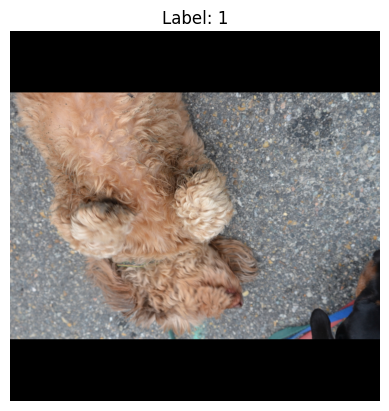

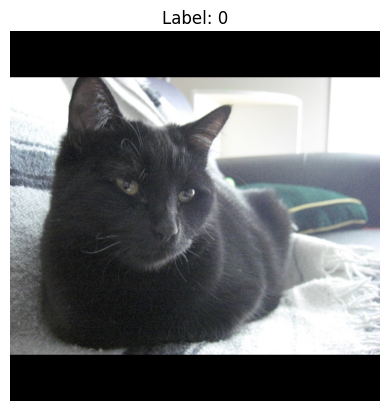

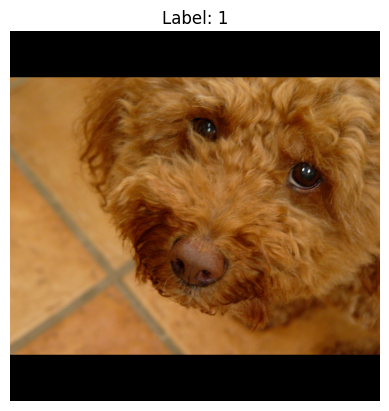

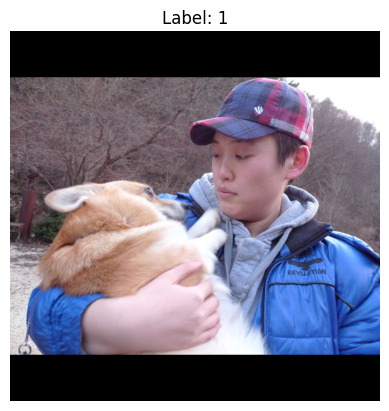

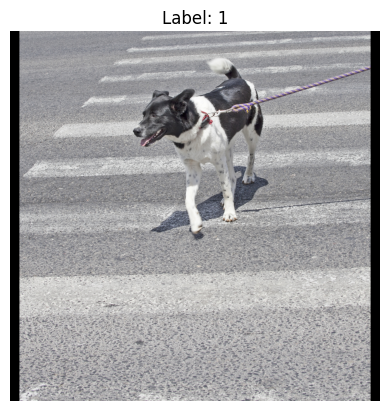

In [ ]:

for i in range(5):
    image, label = train_dataset[i]

    # image shape: (C, H, W)
    channels = image.shape[0]

    if channels == 1:
        plt.imshow(image.squeeze(0), cmap='gray')
    else:
        # For RGB or other multi-channel images
        plt.imshow(image.permute(1, 2, 0))

    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()


# Grayscale Image with padding

In [45]:
def resize_with_padding(image, target_size=1024):

    image = image.convert("L")  

    old_size = image.size  
    ratio = float(target_size) / max(old_size)
    new_size = tuple([int(x * ratio) for x in old_size])

    image = image.resize(new_size, Image.BILINEAR)

    new_image = Image.new("L", (target_size, target_size), color=0)
    paste_position = ((target_size - new_size[0]) // 2,
                      (target_size - new_size[1]) // 2)
    new_image.paste(image, paste_position)
    return new_image

In [46]:
transform = transforms.Compose([
    transforms.Lambda(lambda img: resize_with_padding(img, 1024)),
    transforms.ToTensor()
])

In [47]:
dataset = CocoSingleLabelDataset(
    image_dir="dogs_cats_1box/data",
    annotation_file="dogs_cats_1box/labels.json",
    transform=transform
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [48]:
train_size = math.floor(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

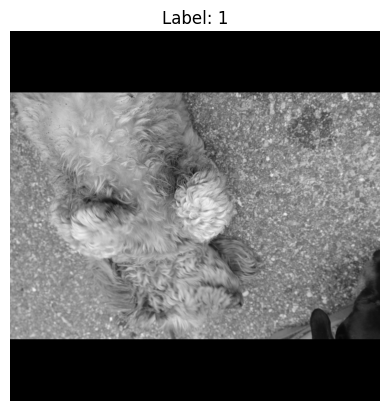

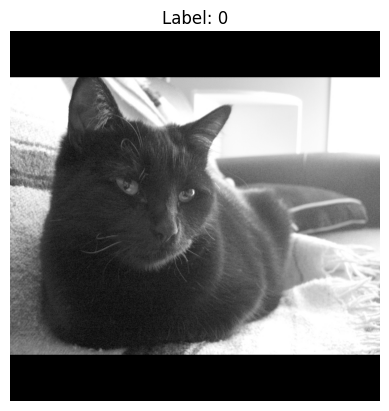

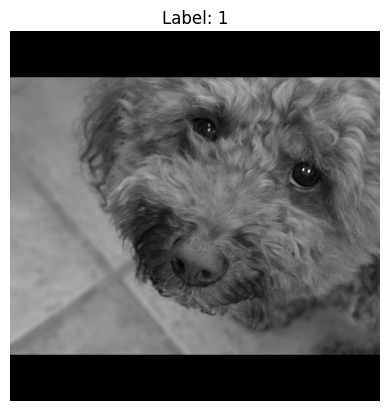

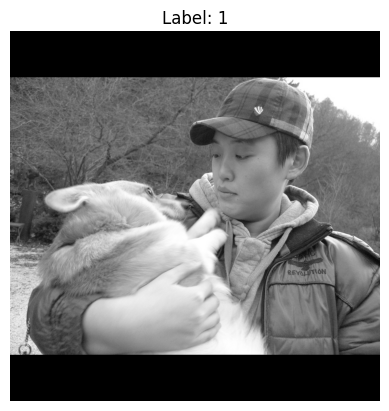

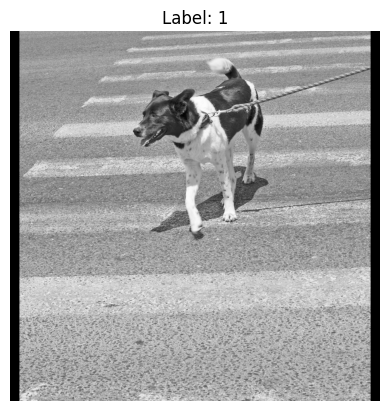

In [49]:

for i in range(5):
    image, label = train_dataset[i]

    # image shape: (C, H, W)
    channels = image.shape[0]

    if channels == 1:
        plt.imshow(image.squeeze(0), cmap='gray')
    else:
        # For RGB or other multi-channel images
        plt.imshow(image.permute(1, 2, 0))

    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()


In [50]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 1024, 1024])
Shape of y: torch.Size([64]) torch.int64


In [51]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [52]:
# 28*28 input nuerons and 512 output neurons
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(1024*1024, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1048576, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [53]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [54]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [55]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [57]:
epochs = 20
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.711294  [   64/  506]
Test Error: 
 Accuracy: 55.9%, Avg loss: 0.746895 

Epoch 2
-------------------------------
loss: 0.700418  [   64/  506]
Test Error: 
 Accuracy: 55.1%, Avg loss: 0.752058 

Epoch 3
-------------------------------
loss: 0.698916  [   64/  506]
Test Error: 
 Accuracy: 54.3%, Avg loss: 0.751606 

Epoch 4
-------------------------------
loss: 0.689670  [   64/  506]
Test Error: 
 Accuracy: 55.1%, Avg loss: 0.754356 

Epoch 5
-------------------------------
loss: 0.686406  [   64/  506]
Test Error: 
 Accuracy: 55.1%, Avg loss: 0.759255 

Epoch 6
-------------------------------
loss: 0.685211  [   64/  506]
Test Error: 
 Accuracy: 54.3%, Avg loss: 0.758268 

Epoch 7
-------------------------------
loss: 0.674894  [   64/  506]
Test Error: 
 Accuracy: 54.3%, Avg loss: 0.762732 

Epoch 8
-------------------------------
loss: 0.673560  [   64/  506]
Test Error: 
 Accuracy: 54.3%, Avg loss: 0.765041 

Epoch 9
----------------